# Model Input EDA — What Your Forecasting Models Actually See

This notebook inspects the **deep-learning sequence inputs** — the exact arrays the
LSTM (`DemandRNN`) ingests from `data/processed/sequences/`:

| Array | Shape | Meaning |
|---|---|---|
| `{split}_X_temporal.npy` | `(N, 26, 32)` | 32 time-varying features over 26 stored weeks (the LSTM uses the **last 10**) |
| `{split}_X_static.npy` | `(N, 21)` | 21 per-series features (one value per sample) |
| `{split}_y.npy` | `(N, 10)` | targets = `log1p(orders)` for horizons h=1..10 |

> **These are the *scaled* values the model sees.** Demand-derived columns are
> `log1p`-transformed first, then every temporal feature is z-scored (mean≈0, std≈1).
> So `num_orders` will look centred near 0 here — that is expected.

The notebook has three parts:
1. **What the models see** — the feature inventory (names, groups, indices).
2. **Correlations** — feature×feature heatmaps + correlation with the target.
3. **Distribution viewer** — pick any feature from a dropdown to see its histogram.


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Locate the repo root so relative data paths work locally AND on Colab ---
def find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src' / 'features.py').exists():
            return p
    for p in [Path('/content/Article_forecast'), Path('/content/article_forecast')]:
        if (p / 'src' / 'features.py').exists():
            return p
    return Path.cwd()

ROOT = find_repo_root()
os.chdir(ROOT)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('Repo root :', ROOT)

# --- Feature names: import from src/features.py, fall back to a hardcoded copy ---
try:
    from features import (
        SEQUENCE_TEMPORAL_COLS, SEQUENCE_STATIC_COLS, SEQUENCE_LOG1P_COLS,
    )
    print('Loaded feature lists from src/features.py')
except Exception as e:
    print('Could not import src/features.py (', e, '); using hardcoded lists')
    SEQUENCE_TEMPORAL_COLS = [
        'num_orders', 'checkout_price', 'base_price', 'discount_rate',
        'log_checkout_price', 'emailer_for_promotion', 'homepage_featured',
        'email_x_discount', 'homepage_x_discount', 'week_number',
        'week_of_year_sin', 'week_of_year_cos',
        'center_week_count', 'center_cat_week_count', 'city_meal_week_count',
        'meal_week_count', 'region_meal_week_count', 'type_meal_week_count',
        'center_week_price_rank', 'meal_week_price_rank',
        'ewm_alpha05', 'ewm_span10', 'ewm_span13', 'ewm_span26',
        'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w',
        'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w',
    ]
    SEQUENCE_STATIC_COLS = [
        'center_type_enc', 'category_enc', 'cuisine_enc', 'op_area',
        'center_mean_orders', 'meal_mean_orders',
        'base_price_max', 'base_price_mean', 'base_price_min',
        'meal_price_max', 'meal_price_mean', 'meal_price_min',
        'meal_count', 'center_cat_count', 'center_cui_count', 'region_meal_count',
        'center_price_rank', 'center_cat_price_rank',
        'meal_city_price_rank', 'meal_price_rank', 'meal_region_price_rank',
    ]
    SEQUENCE_LOG1P_COLS = {
        'num_orders', 'ewm_alpha05', 'ewm_span10', 'ewm_span13', 'ewm_span26',
        'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w',
        'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w',
        'center_week_count', 'center_cat_week_count', 'city_meal_week_count',
        'meal_week_count', 'region_meal_week_count', 'type_meal_week_count',
    }

N_TEMPORAL = len(SEQUENCE_TEMPORAL_COLS)
N_STATIC = len(SEQUENCE_STATIC_COLS)
LOOKBACK = 10  # PAPER_LOOKBACK in src/lstm_model.py: the LSTM uses the LAST 10 stored weeks

_TEMP_SET = set(SEQUENCE_TEMPORAL_COLS)
_STAT_SET = set(SEQUENCE_STATIC_COLS)

def feature_group(name):
    # Human-readable grouping for a feature name.
    n = name
    if n == 'num_orders' or n.startswith('ewm_') or n.startswith('rolling_'):
        return 'demand history'
    if n.endswith('price_rank'):
        return 'price rank'
    if ('price' in n) or n == 'discount_rate':
        return 'price'
    if n in ('emailer_for_promotion', 'homepage_featured',
             'email_x_discount', 'homepage_x_discount'):
        return 'promotion'
    if n in ('week_number', 'week_of_year_sin', 'week_of_year_cos'):
        return 'calendar'
    if n.endswith('_count'):
        return 'counts'
    if n.endswith('_mean_orders'):
        return 'series level'
    if n.endswith('_enc') or n == 'op_area':
        return 'identity / static'
    return 'other'

print(f'{N_TEMPORAL} temporal features, {N_STATIC} static features, LSTM lookback = {LOOKBACK} weeks')


Repo root : e:\Alireza\Article_forecast
Loaded feature lists from src/features.py
32 temporal features, 21 static features, LSTM lookback = 10 weeks


## 1. What the models see

Pick the split with `SPLIT` (`'train'`, `'val'`, or `'eval'`), load the arrays, and
print the full feature inventory.

In [2]:
SPLIT = 'train'   # <<< change to 'val' or 'eval' to inspect a different split
SEQ_DIR = ROOT / 'data' / 'processed' / 'sequences'

_needed = [f'{SPLIT}_X_temporal.npy', f'{SPLIT}_X_static.npy', f'{SPLIT}_y.npy']
_missing = [f for f in _needed if not (SEQ_DIR / f).exists()]
if _missing:
    raise FileNotFoundError(
        f'Sequence arrays not found in {SEQ_DIR}: {_missing}\n'
        'Generate them first, e.g.:\n'
        '    python -c "import sys; sys.path.insert(0, \'src\'); '
        'from features import build_dl_sequences; build_dl_sequences()"'
    )

Xt_full = np.load(SEQ_DIR / f'{SPLIT}_X_temporal.npy')   # (N, 26, 32)
Xs      = np.load(SEQ_DIR / f'{SPLIT}_X_static.npy')      # (N, 21)
y       = np.load(SEQ_DIR / f'{SPLIT}_y.npy')             # (N, 10) log1p targets

Xt = Xt_full[:, -LOOKBACK:, :]   # exactly what the LSTM ingests (last LOOKBACK weeks)
N = Xt.shape[0]

print(f'Split = {SPLIT!r}')
print(f'  X_temporal (stored) : {Xt_full.shape}  ->  model window {Xt.shape}')
print(f'  X_static            : {Xs.shape}')
print(f'  y (log1p targets)   : {y.shape}   (horizons h=1..{y.shape[1]})')
print(f'  samples (N)         : {N:,}')


Split = 'train'
  X_temporal (stored) : (152628, 26, 32)  ->  model window (152628, 10, 32)
  X_static            : (152628, 21)
  y (log1p targets)   : (152628, 10)   (horizons h=1..10)
  samples (N)         : 152,628


In [3]:
# Full feature inventory as a table
rows = []
for i, n in enumerate(SEQUENCE_TEMPORAL_COLS):
    rows.append({'feature': n, 'kind': 'temporal', 'array_index': i,
                 'group': feature_group(n), 'log1p_before_scaling': n in SEQUENCE_LOG1P_COLS})
for i, n in enumerate(SEQUENCE_STATIC_COLS):
    rows.append({'feature': n, 'kind': 'static', 'array_index': i,
                 'group': feature_group(n), 'log1p_before_scaling': n in SEQUENCE_LOG1P_COLS})
feature_registry = pd.DataFrame(rows)

print('Features per (kind, group):')
print(feature_registry.groupby(['kind', 'group']).size().to_string())
print()
with pd.option_context('display.max_rows', None):
    display(feature_registry)


Features per (kind, group):
kind      group            
static    counts                4
          identity / static     4
          price                 6
          price rank            5
          series level          2
temporal  calendar              3
          counts                6
          demand history       13
          price                 4
          price rank            2
          promotion             4



,feature,kind,array_index,group,log1p_before_scaling
0,num_orders,temporal,0,demand history,True
1,checkout_price,temporal,1,price,False
2,base_price,temporal,2,price,False
3,discount_rate,temporal,3,price,False
4,log_checkout_price,temporal,4,price,False
5,emailer_for_promotion,temporal,5,promotion,False
6,homepage_featured,temporal,6,promotion,False
7,email_x_discount,temporal,7,promotion,False
8,homepage_x_discount,temporal,8,promotion,False
9,week_number,temporal,9,calendar,False


## 2. Correlations

For the **temporal** features we use the most-recent week of the model window (the
prediction anchor, `t = -1`) so each sample contributes one row. Static features are
one-per-sample already. The `target_h1` column is the log1p next-week demand.

Correlation frame: (152628, 54)


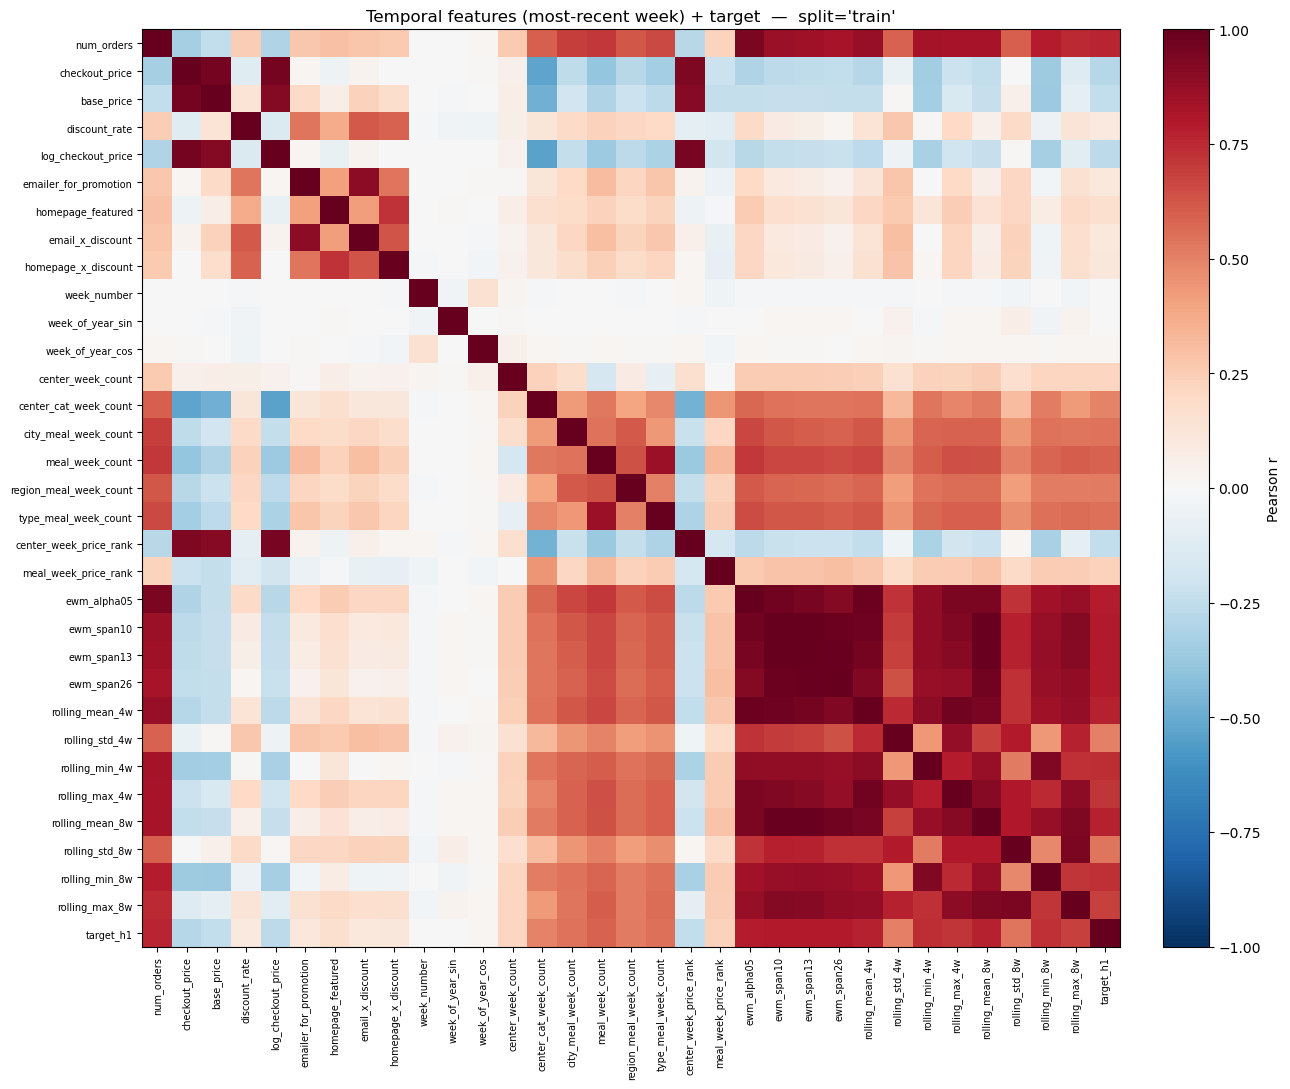

In [4]:
# Build a tidy frame: temporal (most-recent week) + static + target
last_week = Xt[:, -1, :]                                   # (N, N_TEMPORAL)
df_temp = pd.DataFrame(last_week, columns=SEQUENCE_TEMPORAL_COLS)
df_stat = pd.DataFrame(np.asarray(Xs), columns=SEQUENCE_STATIC_COLS)
df_all = pd.concat([df_temp, df_stat], axis=1)
df_all['target_h1'] = y[:, 0]
print('Correlation frame:', df_all.shape)

def plot_corr_heatmap(df, title, figsize=(13, 11)):
    corr = df.corr()
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
    fig.tight_layout()
    plt.show()
    return corr

_ = plot_corr_heatmap(df_temp.assign(target_h1=y[:, 0]),
                      f'Temporal features (most-recent week) + target  —  split={SPLIT!r}')


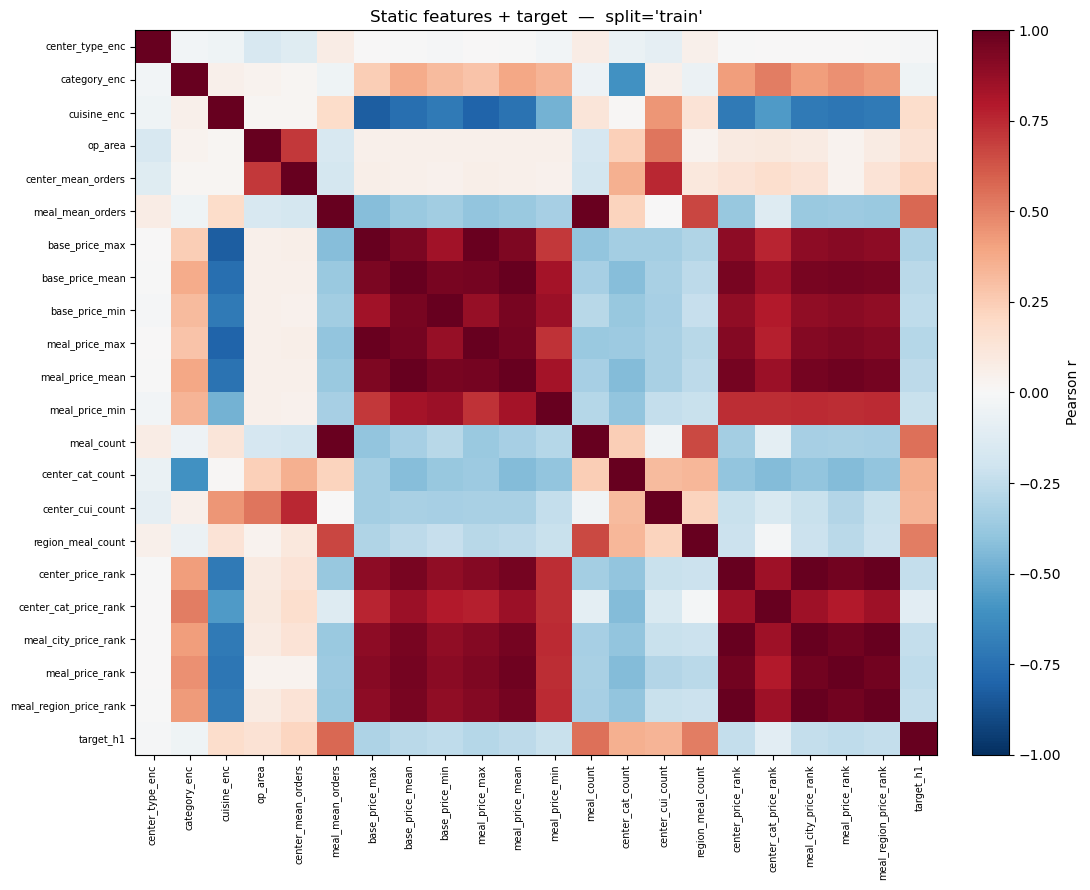

In [5]:
_ = plot_corr_heatmap(df_stat.assign(target_h1=y[:, 0]),
                      f'Static features + target  —  split={SPLIT!r}', figsize=(11, 9))


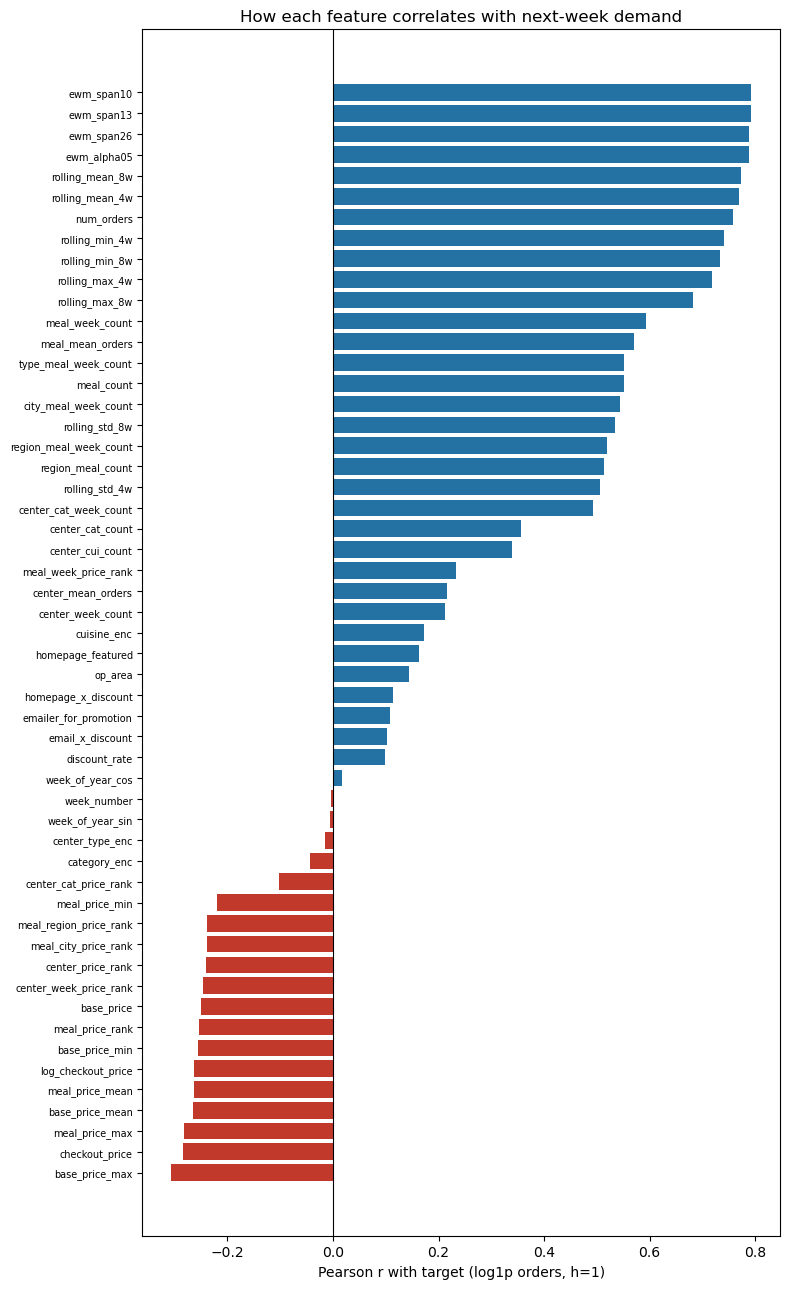

,corr_with_target_h1
ewm_span10,0.792090
ewm_span13,0.791872
ewm_span26,0.789195
ewm_alpha05,0.788212
rolling_mean_8w,0.772398
rolling_mean_4w,0.769550
num_orders,0.757923
rolling_min_4w,0.741183
rolling_min_8w,0.733397
rolling_max_4w,0.717646


In [6]:
# Which features actually correlate with next-week demand?
corr_t = df_all.corr()['target_h1'].drop('target_h1').sort_values()
fig, ax = plt.subplots(figsize=(8, 13))
colors = ['#c0392b' if v < 0 else '#2471a3' for v in corr_t.values]
ax.barh(corr_t.index, corr_t.values, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Pearson r with target (log1p orders, h=1)')
ax.set_title('How each feature correlates with next-week demand')
ax.tick_params(axis='y', labelsize=7)
fig.tight_layout()
plt.show()

corr_t.to_frame('corr_with_target_h1').iloc[::-1]


## 3. Feature distribution viewer

Use the **dropdown** to choose any feature (or a target horizon) and see its
distribution. `bins` and a log y-axis are adjustable. If `ipywidgets` is not
available, the last cell falls back to calling `plot_feature_distribution('name')`
directly — just edit the name.

- **Temporal** features are flattened over all `LOOKBACK` weeks (every value the LSTM reads).
- **Static** features show one value per sample.
- **target_hN** shows the `log1p(orders)` target for horizon N.

In [ ]:
TARGET_NAMES = [f'target_h{h}' for h in range(1, y.shape[1] + 1)]
ALL_FEATURES = list(SEQUENCE_TEMPORAL_COLS) + list(SEQUENCE_STATIC_COLS) + TARGET_NAMES

def get_feature_values(name):
    # Return (values_1d, description) for any temporal/static feature or target horizon.
    if name in _TEMP_SET:
        i = SEQUENCE_TEMPORAL_COLS.index(name)
        return Xt[:, :, i].ravel(), f'temporal - all {LOOKBACK} lookback weeks - array_index {i}'
    if name in _STAT_SET:
        i = SEQUENCE_STATIC_COLS.index(name)
        return np.asarray(Xs)[:, i], f'static - one value per sample - array_index {i}'
    if name in TARGET_NAMES:
        h = int(name.split('_h')[1]) - 1
        return y[:, h], f'target - log1p(orders) - horizon h={h + 1}'
    raise KeyError(f'unknown feature: {name}')

def plot_feature_distribution(name='num_orders', bins=60, log_y=False):
    vals, desc = get_feature_values(name)
    vals = vals[np.isfinite(vals)]
    if name in _TEMP_SET or name in _STAT_SET:
        grp = feature_group(name)
    else:
        grp = 'target'
    is_log = name in SEQUENCE_LOG1P_COLS
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(vals, bins=bins, color='#2471a3', alpha=0.85, edgecolor='white', linewidth=0.3)
    m, md_, sd = float(np.mean(vals)), float(np.median(vals)), float(np.std(vals))
    ax.axvline(m,   color='#c0392b', ls='--', lw=1.5, label=f'mean={m:.3g}')
    ax.axvline(md_, color='#27ae60', ls=':',  lw=1.5, label=f'median={md_:.3g}')
    if log_y:
        ax.set_yscale('log')
    suffix = '  -  log1p-transformed before scaling' if is_log else ''
    ax.set_title(f'{name}   [{grp}]{suffix}')
    ax.set_xlabel(f'value the model sees   ({desc})')
    ax.set_ylabel('count (log)' if log_y else 'count')
    ax.legend(fontsize=8)
    stats = (f'n      = {vals.size:,}\n'
             f'mean   = {m:.4g}\n'
             f'std    = {sd:.4g}\n'
             f'min    = {float(np.min(vals)):.4g}\n'
             f'p25    = {float(np.percentile(vals, 25)):.4g}\n'
             f'p75    = {float(np.percentile(vals, 75)):.4g}\n'
             f'max    = {float(np.max(vals)):.4g}')
    ax.text(0.985, 0.97, stats, transform=ax.transAxes, ha='right', va='top',
            family='monospace', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))
    fig.tight_layout()
    plt.show()

# Interactive dropdown (Jupyter / Colab). Falls back to a direct call otherwise.
try:
    import ipywidgets as widgets
    from IPython.display import display
    widgets.interact(
        plot_feature_distribution,
        name=widgets.Dropdown(options=ALL_FEATURES, value='num_orders', description='feature'),
        bins=widgets.IntSlider(value=60, min=10, max=150, step=5, description='bins'),
        log_y=widgets.Checkbox(value=False, description='log y-axis'),
    )
except Exception as e:
    print('ipywidgets unavailable (', e, ') -> calling plot_feature_distribution directly.')
    print('Available names:', ALL_FEATURES)
    plot_feature_distribution('num_orders')


interactive(children=(Dropdown(description='feature', options=('num_orders', 'checkout_price', 'base_price', '…

### Optional: all distributions at a glance

Small-multiple grids of every temporal and static feature for the current `SPLIT`.

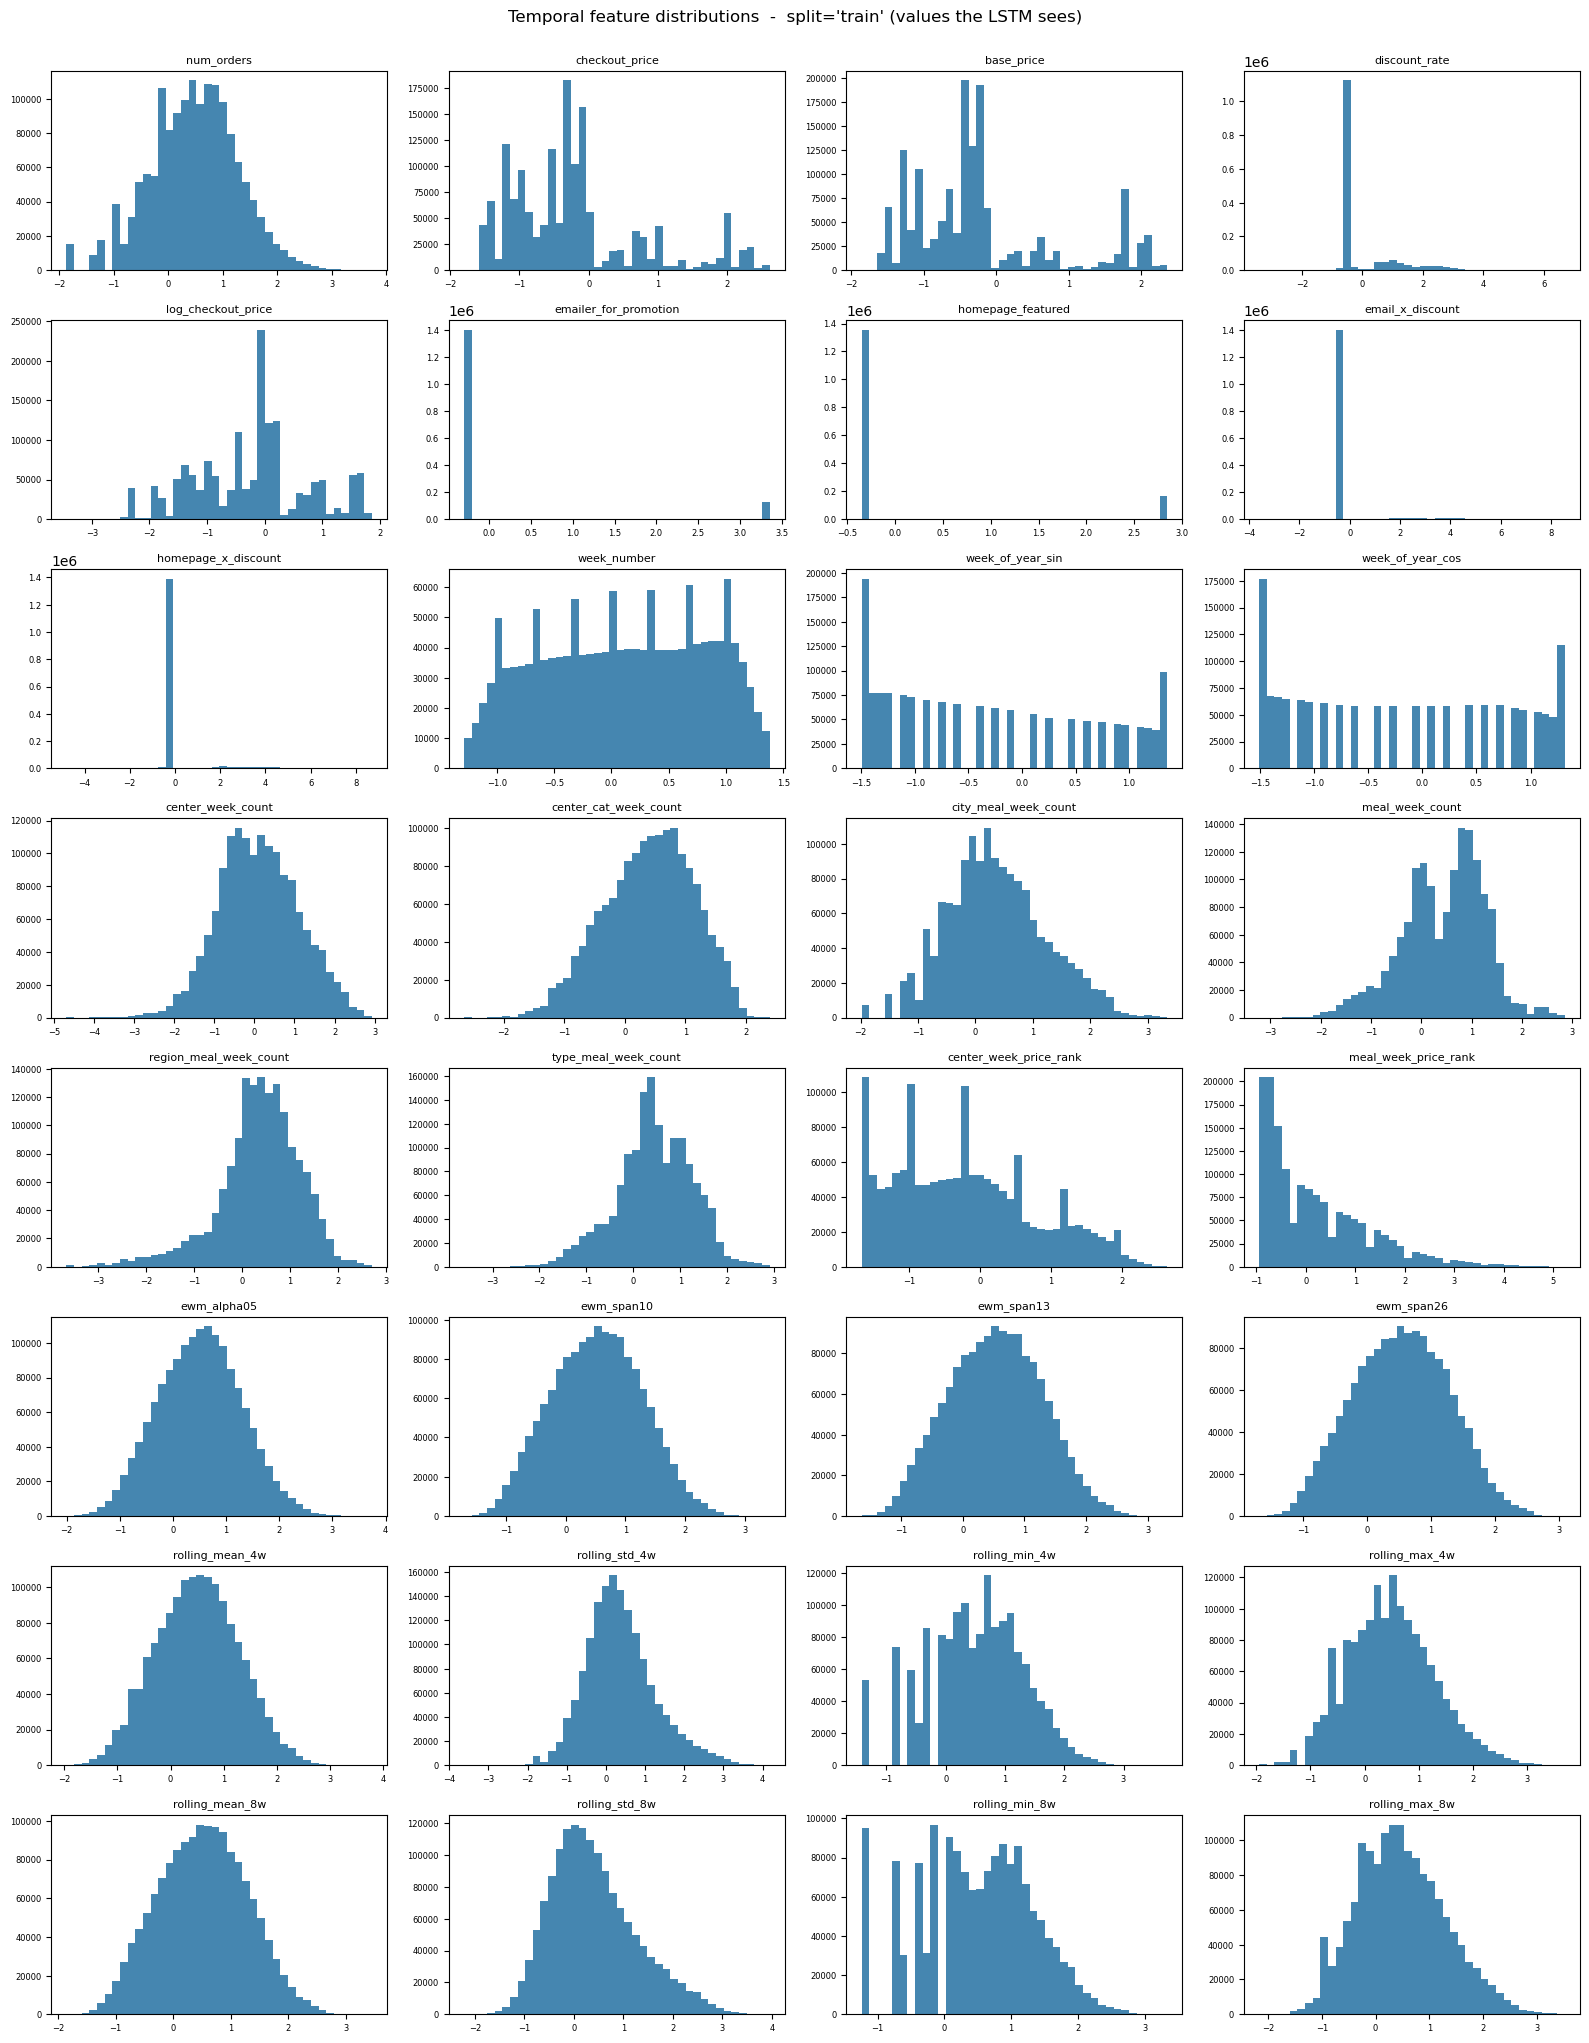

In [8]:
def plot_grid(names, ncols=4, title=''):
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, n in zip(axes, names):
        v = get_feature_values(n)[0]
        v = v[np.isfinite(v)]
        ax.hist(v, bins=40, color='#2471a3', alpha=0.85)
        ax.set_title(n, fontsize=8)
        ax.tick_params(labelsize=6)
    for ax in axes[len(names):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_grid(SEQUENCE_TEMPORAL_COLS, ncols=4,
          title=f'Temporal feature distributions  -  split={SPLIT!r} (values the LSTM sees)')


In [ ]:
plot_grid(SEQUENCE_STATIC_COLS, ncols=4,
          title=f'Static feature distributions  -  split={SPLIT!r}')
